SIMULACIÓN CON 20 ORBITAS / SIMULATION WITH 20 ORBITS

365.69735885301816


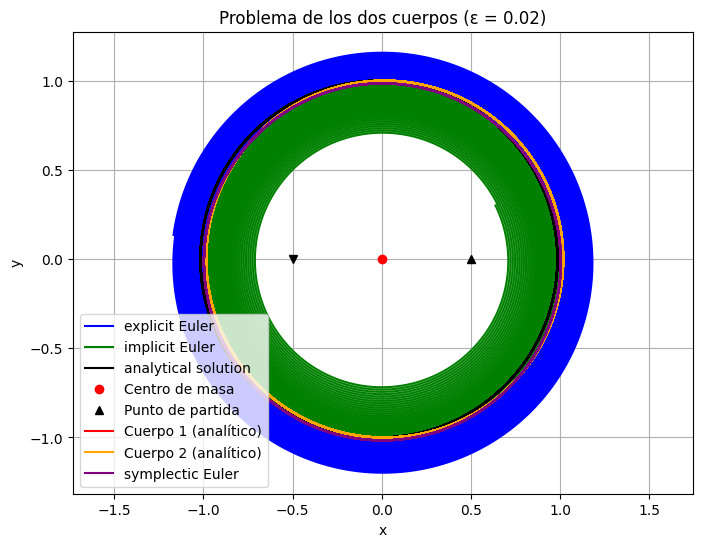

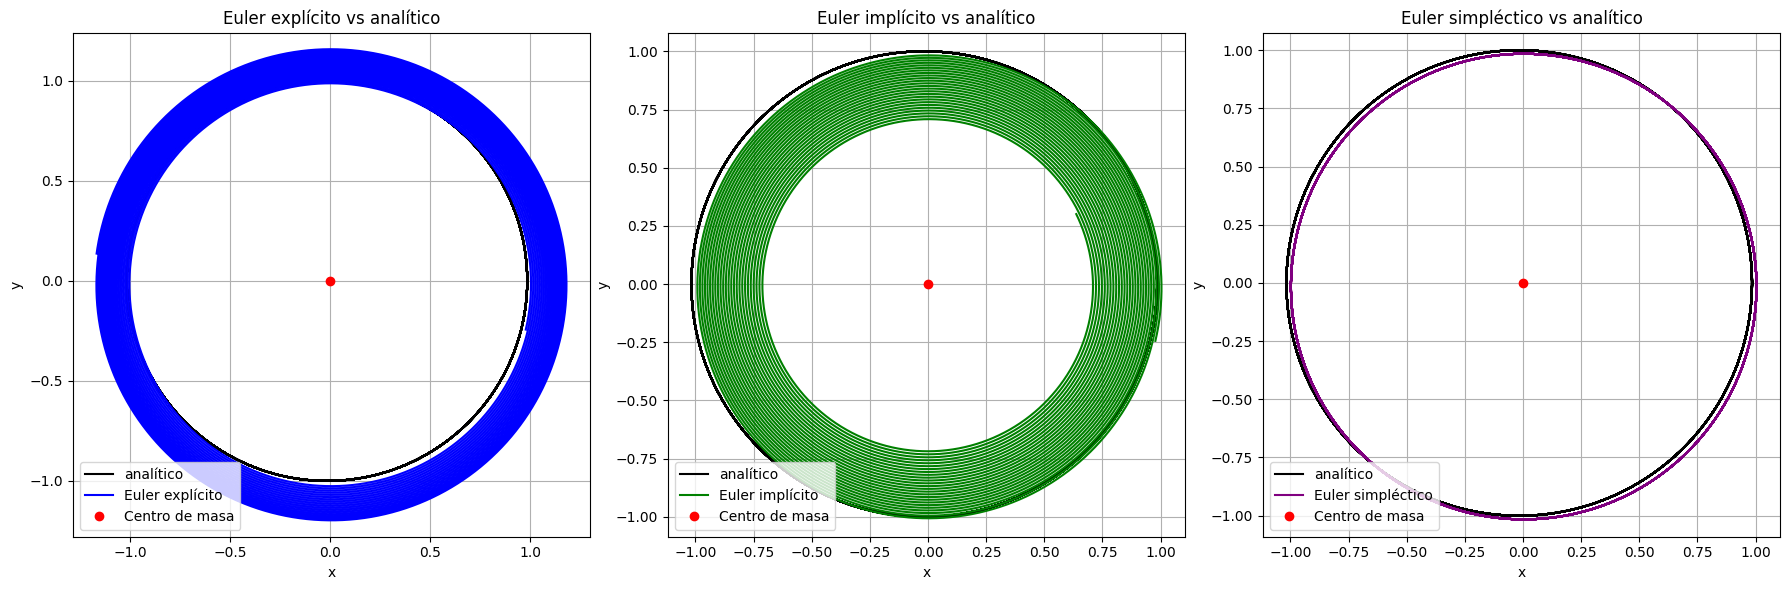

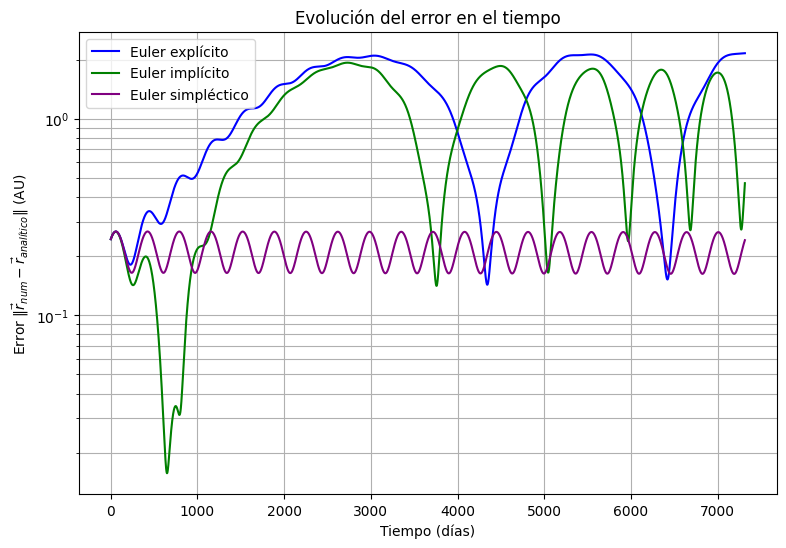

Órbita               Explícito (min/máx)             Implícito (min/máx)           Simpléctico (min/máx)
1             1.810e-01        2.969e-01      1.424e-01        2.667e-01      1.646e-01        2.673e-01
2             2.919e-01        4.439e-01      1.572e-02        1.993e-01      1.645e-01        2.672e-01
3             4.439e-01        6.767e-01      3.112e-02        2.321e-01      1.644e-01        2.670e-01
4             6.768e-01        9.795e-01      2.321e-01        6.017e-01      1.643e-01        2.669e-01
5             9.796e-01        1.324e+00      6.017e-01        1.050e+00      1.642e-01        2.668e-01
6             1.324e+00        1.665e+00      1.050e+00        1.505e+00      1.641e-01        2.667e-01
7             1.665e+00        1.938e+00      1.505e+00        1.834e+00      1.640e-01        2.666e-01
8             1.939e+00        2.063e+00      1.834e+00        1.931e+00      1.639e-01        2.665e-01
9             1.946e+00        2.098e+00      1.369e+00

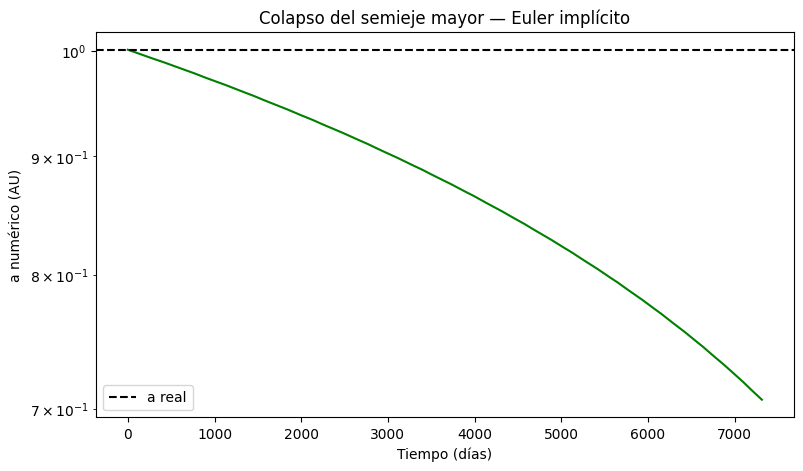

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton, root

#cantidad de orbitas

n_orbitas = 20

#pasos a considerar, notese que entre mayor el paso mejor se notan los cambios,
#en cambio, si usamos pasos muy cortos se extiende el tiempo de compilacion
delta_t = 0.05

# --- Parameters and initial conditions / Parámetros y condiciones iniciales---
G = 2.95912208286e-4   # gravitational constant / constante gravitacional
m1 = 1.0       # masa del sol relativa
m2 = 3.00348959632e-6 # mass de la tierra relativa
M = m1 + m2 # Total mass / Masa total
mu = (m1 * m2) / M

# Start at perihelion on the x-axis / Inicio en el perihelio en el eje x
r0 = np.array([9.773607012272747e-01,-2.440933024736090e-01]) # Initial position / Position initala
v_kreis = np.sqrt(G * M / np.linalg.norm(r0)) # velocity for a circle / velocidad para un circulo
# For a flatter ellipse, use e.g., 1.35 / Para una elipse más plana, usa p.ej. 1.35
v0 = np.array([3.894601620572785e-03, 1.663271328584905e-02])
p0 = v0 * mu

# --- Calculate orbital prameters / Calcular parámetros orbitales ---
r0_norm = np.linalg.norm(r0)
v0_norm = np.linalg.norm(v0)

E_spec = 0.5 * v0_norm**2 - (G * M) / r0_norm # specific energy / energia especifica
a = - (G * M) / (2.0 * E_spec)
h = r0[0]*v0[1] - r0[1]*v0[0] # momentum / momento
epsilon = np.sqrt(1.0 - (h**2) / (G * M * a))

T_orbit = 2.0 * np.pi * np.sqrt(a**3 / (G * M)) #orbital period / periodo orbital
print(T_orbit)
n = np.sqrt(G * M / a**3) # mean motion / movimiento medio

# --- Calculate analytical solution / calcualr solución analitica ---
# evaluate one full orbit t \in [0,T_orbit]
t_eval = np.linspace(0, n_orbitas*T_orbit, n_orbitas*200) #########################################################3
r_analytical = np.zeros((len(t_eval),2))

for i, t in enumerate(t_eval):
    M_anom = n * t # mean anomaly / anomalia media

    # define Kepler's equation / definir ecuacíon de Kepler: f(E) = E-e*sin(E)-M(t) = 0
    def kepler_eq(E):
        return E - epsilon *np.sin(E) - M_anom
    # Derivatvie of Kepler's equation for faster Newton's method/
    # Derivida para el método de Newton
    def kepler_prime(E):
        return 1.0 - epsilon * np.cos(E)

    # Newton's method (M_anom is a good initial guess) / Método de Newton (M_anom es una buena estimación inicial)
    E_sol = newton(kepler_eq, x0=M_anom, fprime=kepler_prime)

    # Calculate de position in the x,y-plane / Calcular posición en el plano x,y
    x = a * (np.cos(E_sol) - epsilon)
    y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)

    r_analytical[i] = [x,y]


# --- Calculate numerical solution using Euler explicit, implicit and symplectic
def grav_force(r):
    r_norm = np.linalg.norm(r)
    return -(G * M * mu) * r / (r_norm**3)

# Explicit Euler

n_steps = int(T_orbit/delta_t)*n_orbitas ###############################################################

r_explicit = np.zeros((n_steps + 1, 2))
p_explicit = np.zeros((n_steps + 1, 2))
r_explicit[0] = r0
p_explicit[0] = p0

for i in range(n_steps):
    r_old = r_explicit[i]
    p_old = p_explicit[i]

    r_explicit[i+1] = r_old + delta_t * (p_old / mu)
    p_explicit[i+1] = p_old + delta_t * grav_force(r_old)

# Implicit Euler

n_steps = n_steps
r_implicit = np.zeros((n_steps + 1, 2))
p_implicit = np.zeros((n_steps + 1, 2))
r_implicit[0] = r0
p_implicit[0] = p0

for i in range(n_steps):
    r_old = r_implicit[i]
    p_old = p_implicit[i]

    def residual(r_next):
        return r_next - r_old - (delta_t / mu) * p_old - (delta_t**2 / mu) * grav_force(r_next)

    r_guess = r_old + delta_t * (p_old/ mu) #explicit step

    sol = root(residual, r_guess)
    r_next = sol.x

    p_next = p_old + delta_t * grav_force(r_next)

    r_implicit[i+1] = r_next
    p_implicit[i+1] = p_next

#Euler simplectico


n_steps = int(T_orbit/delta_t)*n_orbitas   ##################################################################

r_symplectic = np.zeros((n_steps + 1, 2))
p_symplectic = np.zeros((n_steps + 1, 2))
r_symplectic[0] = r0
p_symplectic[0] = p0

for i in range(n_steps):
    r_old = r_symplectic[i]
    p_old = p_symplectic[i]

    r_symplectic[i+1] = r_old + delta_t * (p_old / mu)
    p_symplectic[i+1] = p_old + delta_t * grav_force(r_symplectic[i+1])

# --- Visualization of the relative vector between the two bodies---
plt.figure(figsize=(8, 6))
plt.plot(r_explicit[:, 0], r_explicit[:, 1], label="explicit Euler", color="blue")
plt.plot(r_implicit[:, 0], r_implicit[:, 1], label="implicit Euler", color="green")
plt.plot(r_analytical[:, 0], r_analytical[:, 1], label="analytical solution", color="black")

plt.plot(0, 0, 'ro', label="Centro de masa")
plt.plot(1, 0, 'k^', label = "Punto de partida")


#Visualizacion de los dos cuerpos:
# Conversión del vector relativo a coordenadas del centro de masa
#r1 = +(m2 / M) * r  und  r2 = -(m1 / M) * r
r1_analytical = (m2 / M) * r_analytical
r2_analytical = -(m1 / M) * r_analytical

# plot of the two bodies
plt.plot(r1_analytical[:, 0], r1_analytical[:, 1], label="Cuerpo 1 (analítico)", color="red")
plt.plot(r2_analytical[:, 0], r2_analytical[:, 1], label="Cuerpo 2 (analítico)", color="orange")
plt.plot(r_symplectic[:, 0], r_symplectic[:, 1], label="symplectic Euler", color="purple")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Problema de los dos cuerpos (ε = {epsilon:.2f})")
plt.axis("equal")
plt.legend(loc='lower left')
plt.grid(True)
plt.plot(0.5, 0, 'k^', label = "Punto de partida")
plt.plot(-0.5, 0, 'kv', label = "Punto de partida")

plt.show()

#Visualización: analítico vs cada método por separado
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

metodos = [
    (r_explicit, "Euler explícito", "blue"),
    (r_implicit, "Euler implícito", "green"),
    (r_symplectic, "Euler simpléctico", "purple"),
]

for ax, (r_num, nombre, color) in zip(axs, metodos):
    ax.plot(r_analytical[:, 0], r_analytical[:, 1], label="analítico", color="black")
    ax.plot(r_num[:, 0], r_num[:, 1], label=nombre, color=color)
    ax.plot(0, 0, 'ro', label="Centro de masa")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{nombre} vs analítico")
    ax.axis("equal")
    ax.legend(loc='lower left')
    ax.grid(True)

plt.tight_layout()
plt.show()
###################################################################################################################################################################
# ojo: calcula punto a punto y en consecuencia el codigo compila mas lento, solucionamos vectorizando :)
###################################################################################################################################################################

#t_sync = np.arange(n_steps + 1) * delta_t   # mismos instantes que usa tu loop: t_i = i*delta_t
# r_analytical_sync = np.zeros((n_steps + 1, 2))

# for i, t in enumerate(t_sync):
#     M_anom = n * t
#     E_sol = newton(lambda E: E - epsilon*np.sin(E) - M_anom,
#                     x0=M_anom,
#                     fprime=lambda E: 1.0 - epsilon*np.cos(E))
#     x = a * (np.cos(E_sol) - epsilon)
#     y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)
#     r_analytical_sync[i] = [x, y]

###################################################################################################################################################################



#creamos arreglos a vectorizar


t_sync = np.arange(n_steps + 1) * delta_t
M_anom = n * t_sync

# Newton-Raphson vectorizado: itera sobre TODO el arreglo a la vez
E = M_anom.copy()                      # estimación inicial
for _ in range(6):
    E = E - (E - epsilon*np.sin(E) - M_anom) / (1.0 - epsilon*np.cos(E))

r_analytical_sync = np.column_stack([
    a * (np.cos(E) - epsilon),
    a * np.sqrt(1.0 - epsilon**2) * np.sin(E)
])


#Error por metodo

error_explicit  = np.linalg.norm(r_explicit  - r_analytical_sync, axis=1)
error_implicit  = np.linalg.norm(r_implicit  - r_analytical_sync, axis=1)
error_symplectic = np.linalg.norm(r_symplectic - r_analytical_sync, axis=1)


plt.figure(figsize=(9, 6))
plt.plot(t_sync, error_explicit, label="Euler explícito", color="blue")
plt.plot(t_sync, error_implicit, label="Euler implícito", color="green")
plt.plot(t_sync, error_symplectic, label="Euler simpléctico", color="purple")
plt.xlabel("Tiempo (días)")
plt.ylabel(r"Error $\|\vec r_{num} - \vec r_{analítico}\|$ (AU)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.title("Evolución del error en el tiempo")
plt.show()


# --- Resumen numérico del error, órbita por órbita ---
pasos_por_orbita = int(T_orbit / delta_t)

print(f"{'Órbita':<8}{'Explícito (min/máx)':>32}{'Implícito (min/máx)':>32}{'Simpléctico (min/máx)':>32}")
for k in range(n_orbitas):
    ini = k * pasos_por_orbita
    fin = (k + 1) * pasos_por_orbita

    tramo_exp = error_explicit[ini:fin]
    tramo_imp = error_implicit[ini:fin]
    tramo_sym = error_symplectic[ini:fin]

    print(f"{k+1:<8}"
          f"{tramo_exp.min():>15.3e}{tramo_exp.max():>17.3e}"
          f"{tramo_imp.min():>15.3e}{tramo_imp.max():>17.3e}"
          f"{tramo_sym.min():>15.3e}{tramo_sym.max():>17.3e}")

#como, teoricamente, sabemos que el euler implicito va a ser mala aproximacion hacia el interior de la elipse,
#podemos observar el comportamiento para distintas cantidades de orbitas en un determinado paso

    v_implicit = p_implicit / mu
E_spec_num = 0.5*np.linalg.norm(v_implicit, axis=1)**2 - G*M/np.linalg.norm(r_implicit, axis=1)
a_num_implicit = -G*M/(2.0*E_spec_num)

plt.figure(figsize=(9,5))
plt.plot(t_sync, a_num_implicit, color="green")
plt.axhline(a, color="black", linestyle="--", label="a real")
plt.xlabel("Tiempo (días)")
plt.ylabel("a numérico (AU)")
plt.yscale("log")
plt.legend()
plt.title("Colapso del semieje mayor — Euler implícito")
plt.show()

SIMULACIÓN CON 30 ORBITAS / SIMULATION WITH 30 ORBITS

365.69735885301816


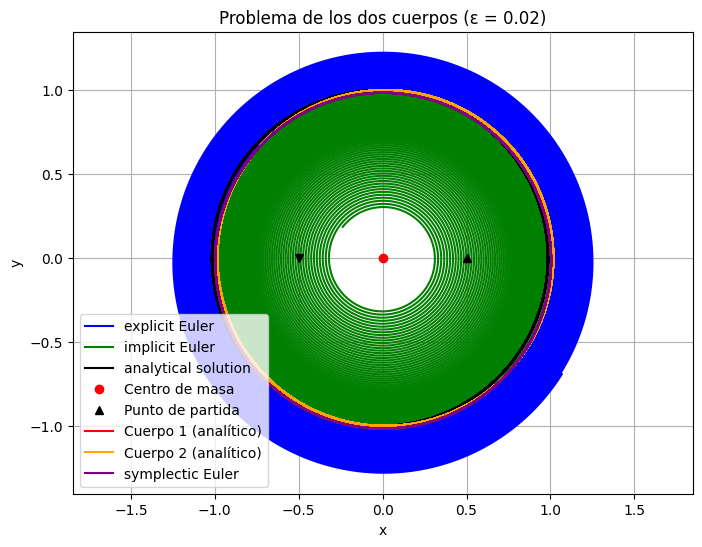

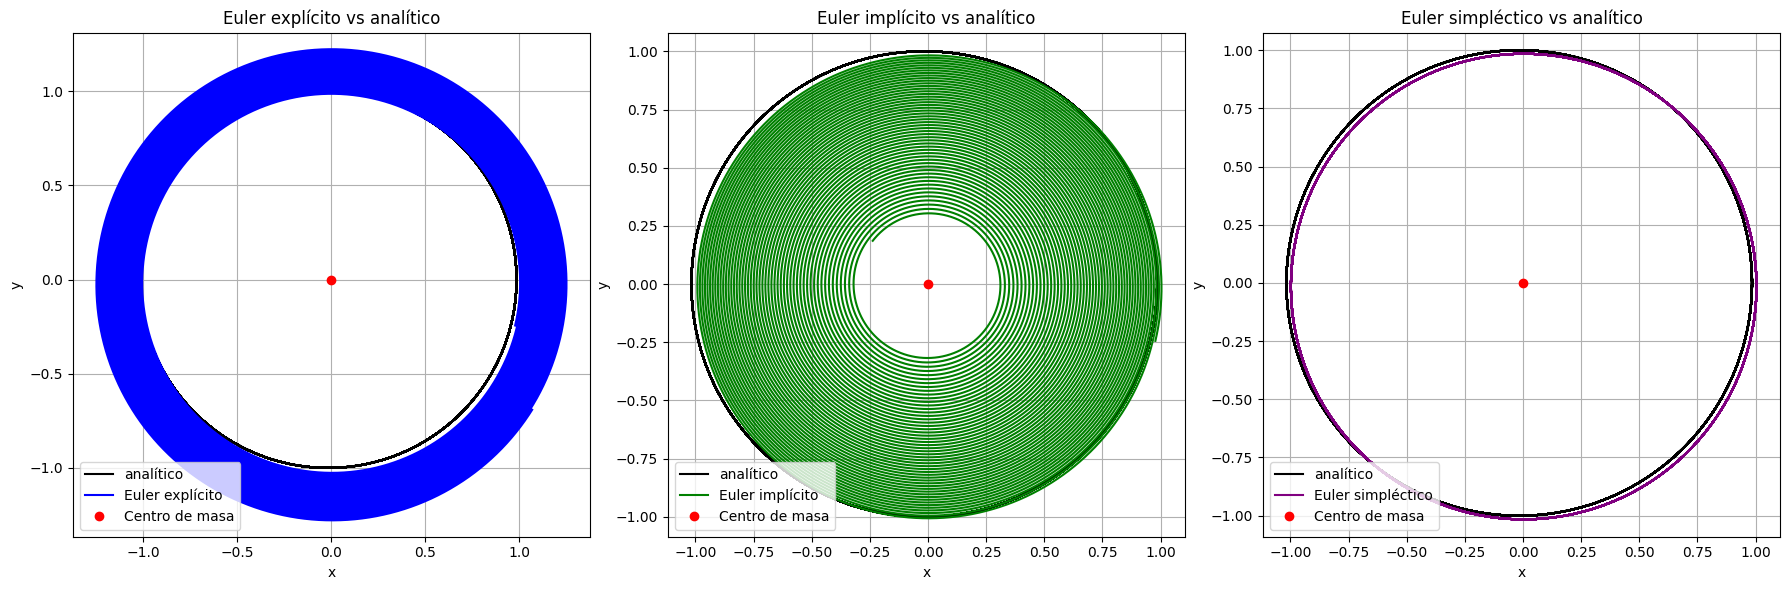

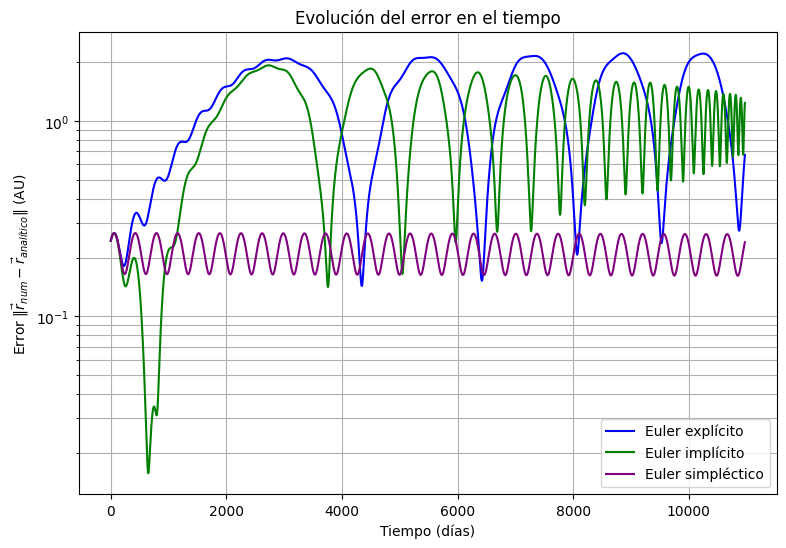

Órbita               Explícito (min/máx)             Implícito (min/máx)           Simpléctico (min/máx)
1             1.810e-01        2.969e-01      1.424e-01        2.667e-01      1.646e-01        2.673e-01
2             2.919e-01        4.439e-01      1.572e-02        1.993e-01      1.645e-01        2.672e-01
3             4.439e-01        6.767e-01      3.112e-02        2.321e-01      1.644e-01        2.670e-01
4             6.768e-01        9.795e-01      2.321e-01        6.017e-01      1.643e-01        2.669e-01
5             9.796e-01        1.324e+00      6.017e-01        1.050e+00      1.642e-01        2.668e-01
6             1.324e+00        1.665e+00      1.050e+00        1.505e+00      1.641e-01        2.667e-01
7             1.665e+00        1.938e+00      1.505e+00        1.834e+00      1.640e-01        2.666e-01
8             1.939e+00        2.063e+00      1.834e+00        1.931e+00      1.639e-01        2.665e-01
9             1.946e+00        2.098e+00      1.369e+00

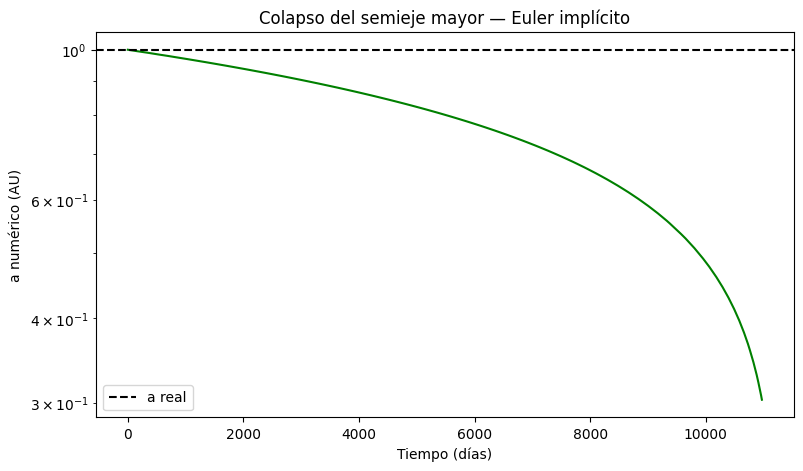

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton, root

#cantidad de orbitas

n_orbitas = 30

#pasos a considerar, notese que entre mayor el paso mejor se notan los cambios,
#en cambio, si usamos pasos muy cortos se extiende el tiempo de compilacion
delta_t = 0.05

# --- Parameters and initial conditions / Parámetros y condiciones iniciales---
G = 2.95912208286e-4   # gravitational constant / constante gravitacional
m1 = 1.0       # masa del sol relativa
m2 = 3.00348959632e-6 # mass de la tierra relativa
M = m1 + m2 # Total mass / Masa total
mu = (m1 * m2) / M

# Start at perihelion on the x-axis / Inicio en el perihelio en el eje x
r0 = np.array([9.773607012272747e-01,-2.440933024736090e-01]) # Initial position / Position initala
v_kreis = np.sqrt(G * M / np.linalg.norm(r0)) # velocity for a circle / velocidad para un circulo
# For a flatter ellipse, use e.g., 1.35 / Para una elipse más plana, usa p.ej. 1.35
v0 = np.array([3.894601620572785e-03, 1.663271328584905e-02])
p0 = v0 * mu

# --- Calculate orbital prameters / Calcular parámetros orbitales ---
r0_norm = np.linalg.norm(r0)
v0_norm = np.linalg.norm(v0)

E_spec = 0.5 * v0_norm**2 - (G * M) / r0_norm # specific energy / energia especifica
a = - (G * M) / (2.0 * E_spec)
h = r0[0]*v0[1] - r0[1]*v0[0] # momentum / momento
epsilon = np.sqrt(1.0 - (h**2) / (G * M * a))

T_orbit = 2.0 * np.pi * np.sqrt(a**3 / (G * M)) #orbital period / periodo orbital
print(T_orbit)
n = np.sqrt(G * M / a**3) # mean motion / movimiento medio

# --- Calculate analytical solution / calcualr solución analitica ---
# evaluate one full orbit t \in [0,T_orbit]
t_eval = np.linspace(0, n_orbitas*T_orbit, n_orbitas*200) #########################################################3
r_analytical = np.zeros((len(t_eval),2))

for i, t in enumerate(t_eval):
    M_anom = n * t # mean anomaly / anomalia media

    # define Kepler's equation / definir ecuacíon de Kepler: f(E) = E-e*sin(E)-M(t) = 0
    def kepler_eq(E):
        return E - epsilon *np.sin(E) - M_anom
    # Derivatvie of Kepler's equation for faster Newton's method/
    # Derivida para el método de Newton
    def kepler_prime(E):
        return 1.0 - epsilon * np.cos(E)

    # Newton's method (M_anom is a good initial guess) / Método de Newton (M_anom es una buena estimación inicial)
    E_sol = newton(kepler_eq, x0=M_anom, fprime=kepler_prime)

    # Calculate de position in the x,y-plane / Calcular posición en el plano x,y
    x = a * (np.cos(E_sol) - epsilon)
    y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)

    r_analytical[i] = [x,y]


# --- Calculate numerical solution using Euler explicit, implicit and symplectic
def grav_force(r):
    r_norm = np.linalg.norm(r)
    return -(G * M * mu) * r / (r_norm**3)

# Explicit Euler

n_steps = int(T_orbit/delta_t)*n_orbitas ###############################################################

r_explicit = np.zeros((n_steps + 1, 2))
p_explicit = np.zeros((n_steps + 1, 2))
r_explicit[0] = r0
p_explicit[0] = p0

for i in range(n_steps):
    r_old = r_explicit[i]
    p_old = p_explicit[i]

    r_explicit[i+1] = r_old + delta_t * (p_old / mu)
    p_explicit[i+1] = p_old + delta_t * grav_force(r_old)

# Implicit Euler

n_steps = n_steps
r_implicit = np.zeros((n_steps + 1, 2))
p_implicit = np.zeros((n_steps + 1, 2))
r_implicit[0] = r0
p_implicit[0] = p0

for i in range(n_steps):
    r_old = r_implicit[i]
    p_old = p_implicit[i]

    def residual(r_next):
        return r_next - r_old - (delta_t / mu) * p_old - (delta_t**2 / mu) * grav_force(r_next)

    r_guess = r_old + delta_t * (p_old/ mu) #explicit step

    sol = root(residual, r_guess)
    r_next = sol.x

    p_next = p_old + delta_t * grav_force(r_next)

    r_implicit[i+1] = r_next
    p_implicit[i+1] = p_next

#Euler simplectico


n_steps = int(T_orbit/delta_t)*n_orbitas   ##################################################################

r_symplectic = np.zeros((n_steps + 1, 2))
p_symplectic = np.zeros((n_steps + 1, 2))
r_symplectic[0] = r0
p_symplectic[0] = p0

for i in range(n_steps):
    r_old = r_symplectic[i]
    p_old = p_symplectic[i]

    r_symplectic[i+1] = r_old + delta_t * (p_old / mu)
    p_symplectic[i+1] = p_old + delta_t * grav_force(r_symplectic[i+1])

# --- Visualization of the relative vector between the two bodies---
plt.figure(figsize=(8, 6))
plt.plot(r_explicit[:, 0], r_explicit[:, 1], label="explicit Euler", color="blue")
plt.plot(r_implicit[:, 0], r_implicit[:, 1], label="implicit Euler", color="green")
plt.plot(r_analytical[:, 0], r_analytical[:, 1], label="analytical solution", color="black")

plt.plot(0, 0, 'ro', label="Centro de masa")
plt.plot(1, 0, 'k^', label = "Punto de partida")


#Visualizacion de los dos cuerpos:
# Conversión del vector relativo a coordenadas del centro de masa
#r1 = +(m2 / M) * r  und  r2 = -(m1 / M) * r
r1_analytical = (m2 / M) * r_analytical
r2_analytical = -(m1 / M) * r_analytical

# plot of the two bodies
plt.plot(r1_analytical[:, 0], r1_analytical[:, 1], label="Cuerpo 1 (analítico)", color="red")
plt.plot(r2_analytical[:, 0], r2_analytical[:, 1], label="Cuerpo 2 (analítico)", color="orange")
plt.plot(r_symplectic[:, 0], r_symplectic[:, 1], label="symplectic Euler", color="purple")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Problema de los dos cuerpos (ε = {epsilon:.2f})")
plt.axis("equal")
plt.legend(loc='lower left')
plt.grid(True)
plt.plot(0.5, 0, 'k^', label = "Punto de partida")
plt.plot(-0.5, 0, 'kv', label = "Punto de partida")

plt.show()

#Visualización: analítico vs cada método por separado
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

metodos = [
    (r_explicit, "Euler explícito", "blue"),
    (r_implicit, "Euler implícito", "green"),
    (r_symplectic, "Euler simpléctico", "purple"),
]

for ax, (r_num, nombre, color) in zip(axs, metodos):
    ax.plot(r_analytical[:, 0], r_analytical[:, 1], label="analítico", color="black")
    ax.plot(r_num[:, 0], r_num[:, 1], label=nombre, color=color)
    ax.plot(0, 0, 'ro', label="Centro de masa")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{nombre} vs analítico")
    ax.axis("equal")
    ax.legend(loc='lower left')
    ax.grid(True)

plt.tight_layout()
plt.show()
###################################################################################################################################################################
# ojo: calcula punto a punto y en consecuencia el codigo compila mas lento, solucionamos vectorizando :)
###################################################################################################################################################################

#t_sync = np.arange(n_steps + 1) * delta_t   # mismos instantes que usa tu loop: t_i = i*delta_t
# r_analytical_sync = np.zeros((n_steps + 1, 2))

# for i, t in enumerate(t_sync):
#     M_anom = n * t
#     E_sol = newton(lambda E: E - epsilon*np.sin(E) - M_anom,
#                     x0=M_anom,
#                     fprime=lambda E: 1.0 - epsilon*np.cos(E))
#     x = a * (np.cos(E_sol) - epsilon)
#     y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)
#     r_analytical_sync[i] = [x, y]

###################################################################################################################################################################



#creamos arreglos a vectorizar


t_sync = np.arange(n_steps + 1) * delta_t
M_anom = n * t_sync

# Newton-Raphson vectorizado: itera sobre TODO el arreglo a la vez
E = M_anom.copy()                      # estimación inicial
for _ in range(6):
    E = E - (E - epsilon*np.sin(E) - M_anom) / (1.0 - epsilon*np.cos(E))

r_analytical_sync = np.column_stack([
    a * (np.cos(E) - epsilon),
    a * np.sqrt(1.0 - epsilon**2) * np.sin(E)
])


#Error por metodo

error_explicit  = np.linalg.norm(r_explicit  - r_analytical_sync, axis=1)
error_implicit  = np.linalg.norm(r_implicit  - r_analytical_sync, axis=1)
error_symplectic = np.linalg.norm(r_symplectic - r_analytical_sync, axis=1)


plt.figure(figsize=(9, 6))
plt.plot(t_sync, error_explicit, label="Euler explícito", color="blue")
plt.plot(t_sync, error_implicit, label="Euler implícito", color="green")
plt.plot(t_sync, error_symplectic, label="Euler simpléctico", color="purple")
plt.xlabel("Tiempo (días)")
plt.ylabel(r"Error $\|\vec r_{num} - \vec r_{analítico}\|$ (AU)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.title("Evolución del error en el tiempo")
plt.show()


# --- Resumen numérico del error, órbita por órbita ---
pasos_por_orbita = int(T_orbit / delta_t)

print(f"{'Órbita':<8}{'Explícito (min/máx)':>32}{'Implícito (min/máx)':>32}{'Simpléctico (min/máx)':>32}")
for k in range(n_orbitas):
    ini = k * pasos_por_orbita
    fin = (k + 1) * pasos_por_orbita

    tramo_exp = error_explicit[ini:fin]
    tramo_imp = error_implicit[ini:fin]
    tramo_sym = error_symplectic[ini:fin]

    print(f"{k+1:<8}"
          f"{tramo_exp.min():>15.3e}{tramo_exp.max():>17.3e}"
          f"{tramo_imp.min():>15.3e}{tramo_imp.max():>17.3e}"
          f"{tramo_sym.min():>15.3e}{tramo_sym.max():>17.3e}")

#como, teoricamente, sabemos que el euler implicito va a ser mala aproximacion hacia el interior de la elipse,
#podemos observar el comportamiento para distintas cantidades de orbitas en un determinado paso

    v_implicit = p_implicit / mu
E_spec_num = 0.5*np.linalg.norm(v_implicit, axis=1)**2 - G*M/np.linalg.norm(r_implicit, axis=1)
a_num_implicit = -G*M/(2.0*E_spec_num)

plt.figure(figsize=(9,5))
plt.plot(t_sync, a_num_implicit, color="green")
plt.axhline(a, color="black", linestyle="--", label="a real")
plt.xlabel("Tiempo (días)")
plt.ylabel("a numérico (AU)")
plt.yscale("log")
plt.legend()
plt.title("Colapso del semieje mayor — Euler implícito")
plt.show()

SIMULACION CON 40 ORBITAS / SIMULATION WITH 40 ORBITS

365.69735885301816


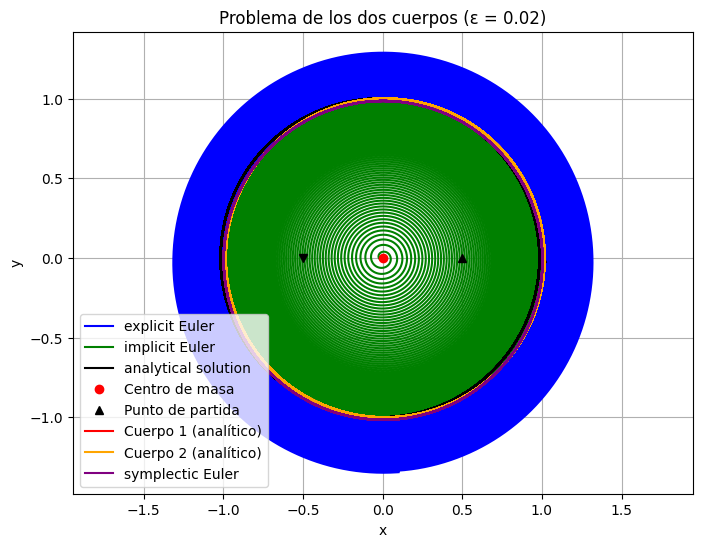

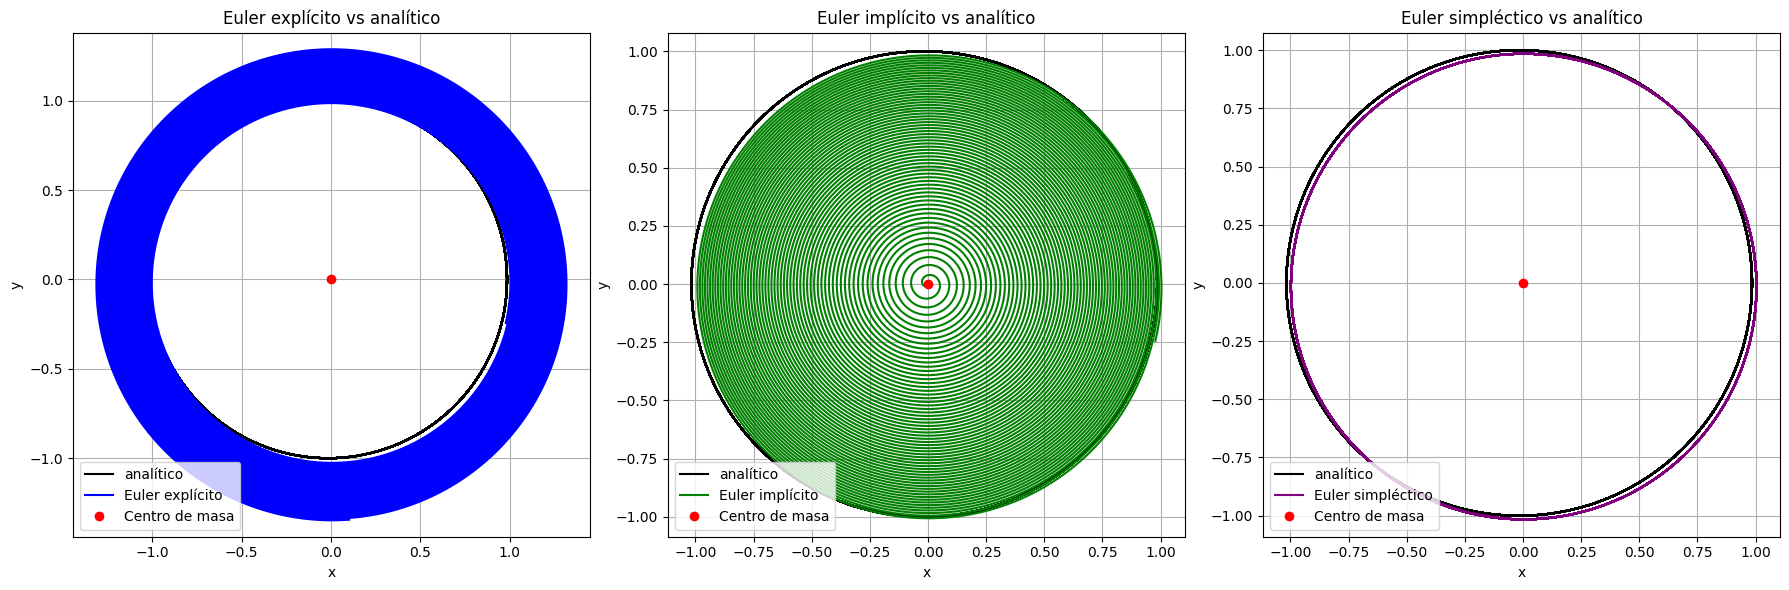

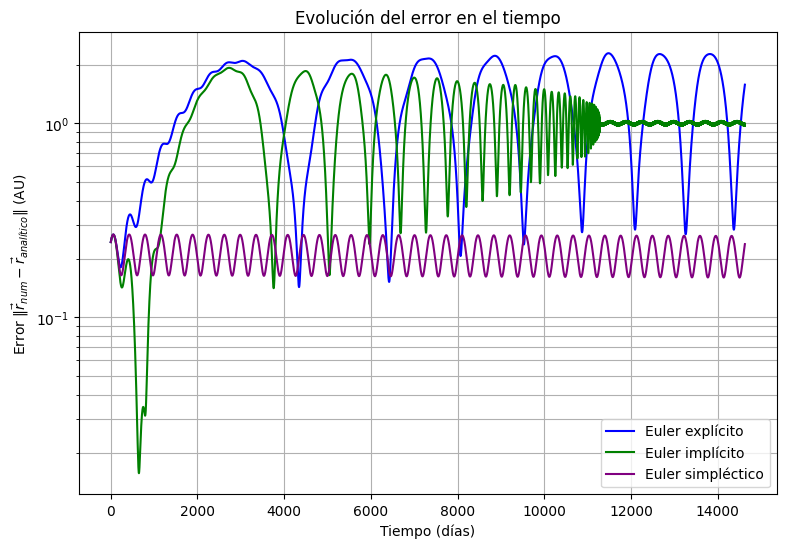

Órbita               Explícito (min/máx)             Implícito (min/máx)           Simpléctico (min/máx)
1             1.810e-01        2.969e-01      1.424e-01        2.667e-01      1.646e-01        2.673e-01
2             2.919e-01        4.439e-01      1.572e-02        1.993e-01      1.645e-01        2.672e-01
3             4.439e-01        6.767e-01      3.112e-02        2.321e-01      1.644e-01        2.670e-01
4             6.768e-01        9.795e-01      2.321e-01        6.017e-01      1.643e-01        2.669e-01
5             9.796e-01        1.324e+00      6.017e-01        1.050e+00      1.642e-01        2.668e-01
6             1.324e+00        1.665e+00      1.050e+00        1.505e+00      1.641e-01        2.667e-01
7             1.665e+00        1.938e+00      1.505e+00        1.834e+00      1.640e-01        2.666e-01
8             1.939e+00        2.063e+00      1.834e+00        1.931e+00      1.639e-01        2.665e-01
9             1.946e+00        2.098e+00      1.369e+00

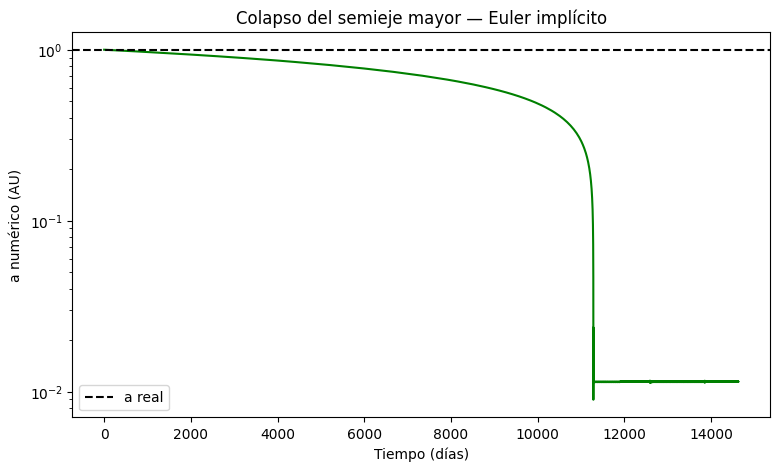

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton, root

#cantidad de orbitas

n_orbitas = 40

#pasos a considerar, notese que entre mayor el paso mejor se notan los cambios,
#en cambio, si usamos pasos muy cortos se extiende el tiempo de compilacion
delta_t = 0.05

# --- Parameters and initial conditions / Parámetros y condiciones iniciales---
G = 2.95912208286e-4   # gravitational constant / constante gravitacional
m1 = 1.0       # masa del sol relativa
m2 = 3.00348959632e-6 # mass de la tierra relativa
M = m1 + m2 # Total mass / Masa total
mu = (m1 * m2) / M

# Start at perihelion on the x-axis / Inicio en el perihelio en el eje x
r0 = np.array([9.773607012272747e-01,-2.440933024736090e-01]) # Initial position / Position initala
v_kreis = np.sqrt(G * M / np.linalg.norm(r0)) # velocity for a circle / velocidad para un circulo
# For a flatter ellipse, use e.g., 1.35 / Para una elipse más plana, usa p.ej. 1.35
v0 = np.array([3.894601620572785e-03, 1.663271328584905e-02])
p0 = v0 * mu

# --- Calculate orbital prameters / Calcular parámetros orbitales ---
r0_norm = np.linalg.norm(r0)
v0_norm = np.linalg.norm(v0)

E_spec = 0.5 * v0_norm**2 - (G * M) / r0_norm # specific energy / energia especifica
a = - (G * M) / (2.0 * E_spec)
h = r0[0]*v0[1] - r0[1]*v0[0] # momentum / momento
epsilon = np.sqrt(1.0 - (h**2) / (G * M * a))

T_orbit = 2.0 * np.pi * np.sqrt(a**3 / (G * M)) #orbital period / periodo orbital
print(T_orbit)
n = np.sqrt(G * M / a**3) # mean motion / movimiento medio

# --- Calculate analytical solution / calcualr solución analitica ---
# evaluate one full orbit t \in [0,T_orbit]
t_eval = np.linspace(0, n_orbitas*T_orbit, n_orbitas*200) #########################################################3
r_analytical = np.zeros((len(t_eval),2))

for i, t in enumerate(t_eval):
    M_anom = n * t # mean anomaly / anomalia media

    # define Kepler's equation / definir ecuacíon de Kepler: f(E) = E-e*sin(E)-M(t) = 0
    def kepler_eq(E):
        return E - epsilon *np.sin(E) - M_anom
    # Derivatvie of Kepler's equation for faster Newton's method/
    # Derivida para el método de Newton
    def kepler_prime(E):
        return 1.0 - epsilon * np.cos(E)

    # Newton's method (M_anom is a good initial guess) / Método de Newton (M_anom es una buena estimación inicial)
    E_sol = newton(kepler_eq, x0=M_anom, fprime=kepler_prime)

    # Calculate de position in the x,y-plane / Calcular posición en el plano x,y
    x = a * (np.cos(E_sol) - epsilon)
    y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)

    r_analytical[i] = [x,y]


# --- Calculate numerical solution using Euler explicit, implicit and symplectic
def grav_force(r):
    r_norm = np.linalg.norm(r)
    return -(G * M * mu) * r / (r_norm**3)

# Explicit Euler

n_steps = int(T_orbit/delta_t)*n_orbitas ###############################################################

r_explicit = np.zeros((n_steps + 1, 2))
p_explicit = np.zeros((n_steps + 1, 2))
r_explicit[0] = r0
p_explicit[0] = p0

for i in range(n_steps):
    r_old = r_explicit[i]
    p_old = p_explicit[i]

    r_explicit[i+1] = r_old + delta_t * (p_old / mu)
    p_explicit[i+1] = p_old + delta_t * grav_force(r_old)

# Implicit Euler

n_steps = n_steps
r_implicit = np.zeros((n_steps + 1, 2))
p_implicit = np.zeros((n_steps + 1, 2))
r_implicit[0] = r0
p_implicit[0] = p0

for i in range(n_steps):
    r_old = r_implicit[i]
    p_old = p_implicit[i]

    def residual(r_next):
        return r_next - r_old - (delta_t / mu) * p_old - (delta_t**2 / mu) * grav_force(r_next)

    r_guess = r_old + delta_t * (p_old/ mu) #explicit step

    sol = root(residual, r_guess)
    r_next = sol.x

    p_next = p_old + delta_t * grav_force(r_next)

    r_implicit[i+1] = r_next
    p_implicit[i+1] = p_next

#Euler simplectico


n_steps = int(T_orbit/delta_t)*n_orbitas   ##################################################################

r_symplectic = np.zeros((n_steps + 1, 2))
p_symplectic = np.zeros((n_steps + 1, 2))
r_symplectic[0] = r0
p_symplectic[0] = p0

for i in range(n_steps):
    r_old = r_symplectic[i]
    p_old = p_symplectic[i]

    r_symplectic[i+1] = r_old + delta_t * (p_old / mu)
    p_symplectic[i+1] = p_old + delta_t * grav_force(r_symplectic[i+1])

# --- Visualization of the relative vector between the two bodies---
plt.figure(figsize=(8, 6))
plt.plot(r_explicit[:, 0], r_explicit[:, 1], label="explicit Euler", color="blue")
plt.plot(r_implicit[:, 0], r_implicit[:, 1], label="implicit Euler", color="green")
plt.plot(r_analytical[:, 0], r_analytical[:, 1], label="analytical solution", color="black")

plt.plot(0, 0, 'ro', label="Centro de masa")
plt.plot(1, 0, 'k^', label = "Punto de partida")


#Visualizacion de los dos cuerpos:
# Conversión del vector relativo a coordenadas del centro de masa
#r1 = +(m2 / M) * r  und  r2 = -(m1 / M) * r
r1_analytical = (m2 / M) * r_analytical
r2_analytical = -(m1 / M) * r_analytical

# plot of the two bodies
plt.plot(r1_analytical[:, 0], r1_analytical[:, 1], label="Cuerpo 1 (analítico)", color="red")
plt.plot(r2_analytical[:, 0], r2_analytical[:, 1], label="Cuerpo 2 (analítico)", color="orange")
plt.plot(r_symplectic[:, 0], r_symplectic[:, 1], label="symplectic Euler", color="purple")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Problema de los dos cuerpos (ε = {epsilon:.2f})")
plt.axis("equal")
plt.legend(loc='lower left')
plt.grid(True)
plt.plot(0.5, 0, 'k^', label = "Punto de partida")
plt.plot(-0.5, 0, 'kv', label = "Punto de partida")

plt.show()

#Visualización: analítico vs cada método por separado
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

metodos = [
    (r_explicit, "Euler explícito", "blue"),
    (r_implicit, "Euler implícito", "green"),
    (r_symplectic, "Euler simpléctico", "purple"),
]

for ax, (r_num, nombre, color) in zip(axs, metodos):
    ax.plot(r_analytical[:, 0], r_analytical[:, 1], label="analítico", color="black")
    ax.plot(r_num[:, 0], r_num[:, 1], label=nombre, color=color)
    ax.plot(0, 0, 'ro', label="Centro de masa")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{nombre} vs analítico")
    ax.axis("equal")
    ax.legend(loc='lower left')
    ax.grid(True)

plt.tight_layout()
plt.show()
###################################################################################################################################################################
# ojo: calcula punto a punto y en consecuencia el codigo compila mas lento, solucionamos vectorizando :)
###################################################################################################################################################################

#t_sync = np.arange(n_steps + 1) * delta_t   # mismos instantes que usa tu loop: t_i = i*delta_t
# r_analytical_sync = np.zeros((n_steps + 1, 2))

# for i, t in enumerate(t_sync):
#     M_anom = n * t
#     E_sol = newton(lambda E: E - epsilon*np.sin(E) - M_anom,
#                     x0=M_anom,
#                     fprime=lambda E: 1.0 - epsilon*np.cos(E))
#     x = a * (np.cos(E_sol) - epsilon)
#     y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)
#     r_analytical_sync[i] = [x, y]

###################################################################################################################################################################



#creamos arreglos a vectorizar


t_sync = np.arange(n_steps + 1) * delta_t
M_anom = n * t_sync

# Newton-Raphson vectorizado: itera sobre TODO el arreglo a la vez
E = M_anom.copy()                      # estimación inicial
for _ in range(6):
    E = E - (E - epsilon*np.sin(E) - M_anom) / (1.0 - epsilon*np.cos(E))

r_analytical_sync = np.column_stack([
    a * (np.cos(E) - epsilon),
    a * np.sqrt(1.0 - epsilon**2) * np.sin(E)
])


#Error por metodo

error_explicit  = np.linalg.norm(r_explicit  - r_analytical_sync, axis=1)
error_implicit  = np.linalg.norm(r_implicit  - r_analytical_sync, axis=1)
error_symplectic = np.linalg.norm(r_symplectic - r_analytical_sync, axis=1)


plt.figure(figsize=(9, 6))
plt.plot(t_sync, error_explicit, label="Euler explícito", color="blue")
plt.plot(t_sync, error_implicit, label="Euler implícito", color="green")
plt.plot(t_sync, error_symplectic, label="Euler simpléctico", color="purple")
plt.xlabel("Tiempo (días)")
plt.ylabel(r"Error $\|\vec r_{num} - \vec r_{analítico}\|$ (AU)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.title("Evolución del error en el tiempo")
plt.show()


# --- Resumen numérico del error, órbita por órbita ---
pasos_por_orbita = int(T_orbit / delta_t)

print(f"{'Órbita':<8}{'Explícito (min/máx)':>32}{'Implícito (min/máx)':>32}{'Simpléctico (min/máx)':>32}")
for k in range(n_orbitas):
    ini = k * pasos_por_orbita
    fin = (k + 1) * pasos_por_orbita

    tramo_exp = error_explicit[ini:fin]
    tramo_imp = error_implicit[ini:fin]
    tramo_sym = error_symplectic[ini:fin]

    print(f"{k+1:<8}"
          f"{tramo_exp.min():>15.3e}{tramo_exp.max():>17.3e}"
          f"{tramo_imp.min():>15.3e}{tramo_imp.max():>17.3e}"
          f"{tramo_sym.min():>15.3e}{tramo_sym.max():>17.3e}")

#como, teoricamente, sabemos que el euler implicito va a ser mala aproximacion hacia el interior de la elipse,
#podemos observar el comportamiento para distintas cantidades de orbitas en un determinado paso

    v_implicit = p_implicit / mu
E_spec_num = 0.5*np.linalg.norm(v_implicit, axis=1)**2 - G*M/np.linalg.norm(r_implicit, axis=1)
a_num_implicit = -G*M/(2.0*E_spec_num)

plt.figure(figsize=(9,5))
plt.plot(t_sync, a_num_implicit, color="green")
plt.axhline(a, color="black", linestyle="--", label="a real")
plt.xlabel("Tiempo (días)")
plt.ylabel("a numérico (AU)")
plt.yscale("log")
plt.legend()
plt.title("Colapso del semieje mayor — Euler implícito")
plt.show()

SIMULACION CON 50 ORBITAS / SIMULATION WITH 50 ORBITS



365.69735885301816


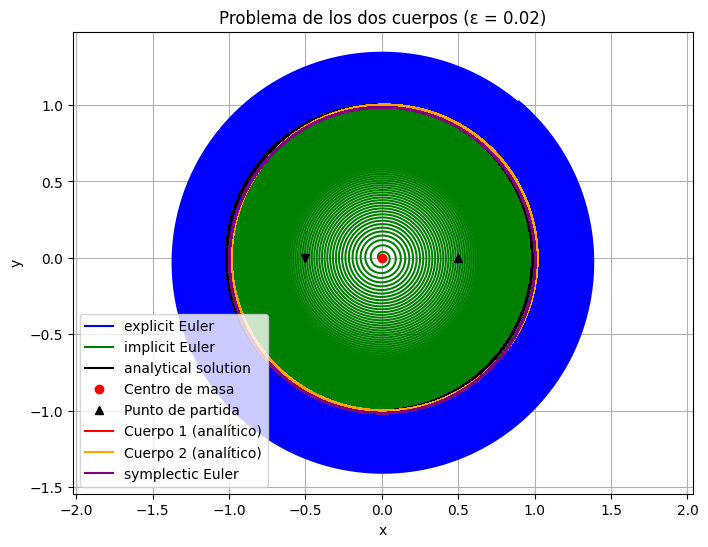

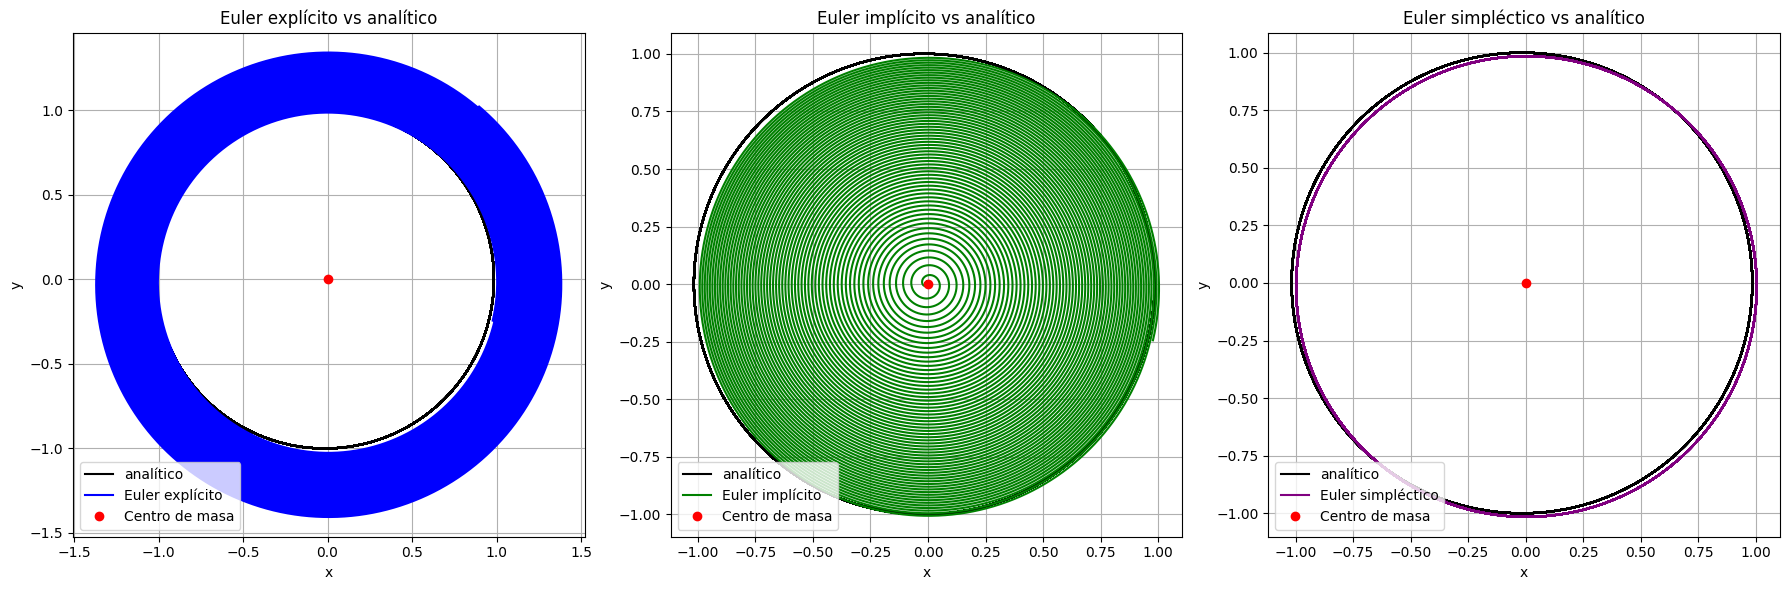

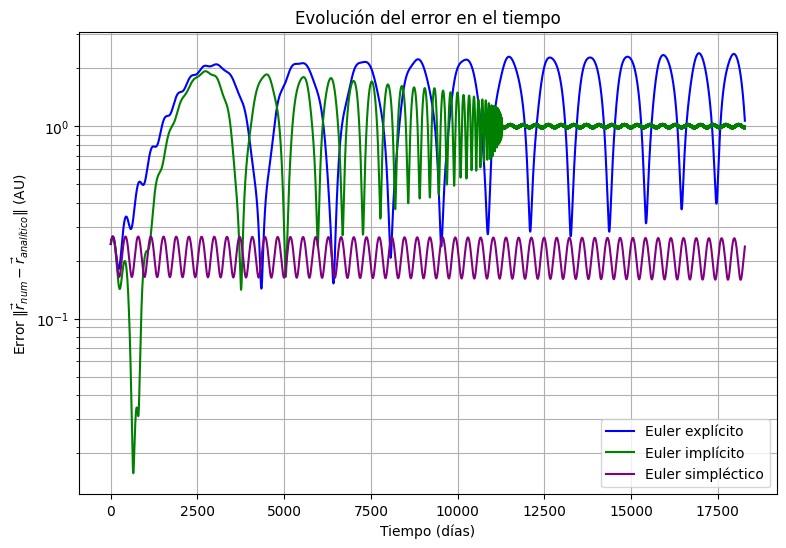

Órbita               Explícito (min/máx)             Implícito (min/máx)           Simpléctico (min/máx)
1             1.810e-01        2.969e-01      1.424e-01        2.667e-01      1.646e-01        2.673e-01
2             2.919e-01        4.439e-01      1.572e-02        1.993e-01      1.645e-01        2.672e-01
3             4.439e-01        6.767e-01      3.112e-02        2.321e-01      1.644e-01        2.670e-01
4             6.768e-01        9.795e-01      2.321e-01        6.017e-01      1.643e-01        2.669e-01
5             9.796e-01        1.324e+00      6.017e-01        1.050e+00      1.642e-01        2.668e-01
6             1.324e+00        1.665e+00      1.050e+00        1.505e+00      1.641e-01        2.667e-01
7             1.665e+00        1.938e+00      1.505e+00        1.834e+00      1.640e-01        2.666e-01
8             1.939e+00        2.063e+00      1.834e+00        1.931e+00      1.639e-01        2.665e-01
9             1.946e+00        2.098e+00      1.369e+00

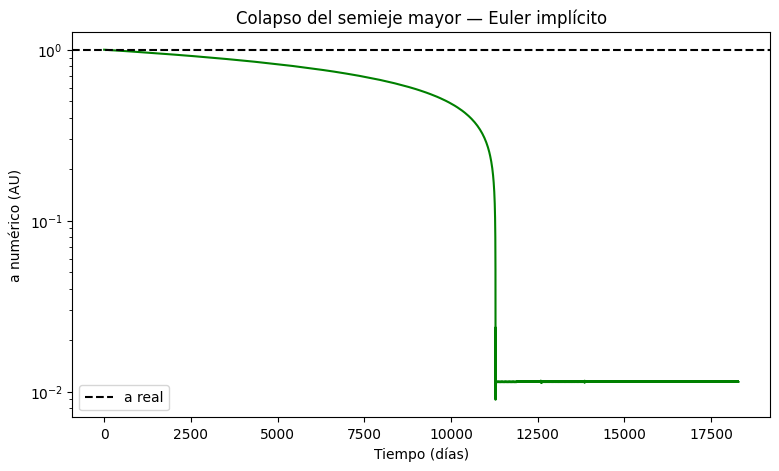

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton, root

#cantidad de orbitas

n_orbitas = 50

#pasos a considerar, notese que entre mayor el paso mejor se notan los cambios,
#en cambio, si usamos pasos muy cortos se extiende el tiempo de compilacion
delta_t = 0.05

# --- Parameters and initial conditions / Parámetros y condiciones iniciales---
G = 2.95912208286e-4   # gravitational constant / constante gravitacional
m1 = 1.0       # masa del sol relativa
m2 = 3.00348959632e-6 # mass de la tierra relativa
M = m1 + m2 # Total mass / Masa total
mu = (m1 * m2) / M

# Start at perihelion on the x-axis / Inicio en el perihelio en el eje x
r0 = np.array([9.773607012272747e-01,-2.440933024736090e-01]) # Initial position / Position initala
v_kreis = np.sqrt(G * M / np.linalg.norm(r0)) # velocity for a circle / velocidad para un circulo
# For a flatter ellipse, use e.g., 1.35 / Para una elipse más plana, usa p.ej. 1.35
v0 = np.array([3.894601620572785e-03, 1.663271328584905e-02])
p0 = v0 * mu

# --- Calculate orbital prameters / Calcular parámetros orbitales ---
r0_norm = np.linalg.norm(r0)
v0_norm = np.linalg.norm(v0)

E_spec = 0.5 * v0_norm**2 - (G * M) / r0_norm # specific energy / energia especifica
a = - (G * M) / (2.0 * E_spec)
h = r0[0]*v0[1] - r0[1]*v0[0] # momentum / momento
epsilon = np.sqrt(1.0 - (h**2) / (G * M * a))

T_orbit = 2.0 * np.pi * np.sqrt(a**3 / (G * M)) #orbital period / periodo orbital
print(T_orbit)
n = np.sqrt(G * M / a**3) # mean motion / movimiento medio

# --- Calculate analytical solution / calcualr solución analitica ---
# evaluate one full orbit t \in [0,T_orbit]
t_eval = np.linspace(0, n_orbitas*T_orbit, n_orbitas*200) #########################################################3
r_analytical = np.zeros((len(t_eval),2))

for i, t in enumerate(t_eval):
    M_anom = n * t # mean anomaly / anomalia media

    # define Kepler's equation / definir ecuacíon de Kepler: f(E) = E-e*sin(E)-M(t) = 0
    def kepler_eq(E):
        return E - epsilon *np.sin(E) - M_anom
    # Derivatvie of Kepler's equation for faster Newton's method/
    # Derivida para el método de Newton
    def kepler_prime(E):
        return 1.0 - epsilon * np.cos(E)

    # Newton's method (M_anom is a good initial guess) / Método de Newton (M_anom es una buena estimación inicial)
    E_sol = newton(kepler_eq, x0=M_anom, fprime=kepler_prime)

    # Calculate de position in the x,y-plane / Calcular posición en el plano x,y
    x = a * (np.cos(E_sol) - epsilon)
    y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)

    r_analytical[i] = [x,y]


# --- Calculate numerical solution using Euler explicit, implicit and symplectic
def grav_force(r):
    r_norm = np.linalg.norm(r)
    return -(G * M * mu) * r / (r_norm**3)

# Explicit Euler

n_steps = int(T_orbit/delta_t)*n_orbitas ###############################################################

r_explicit = np.zeros((n_steps + 1, 2))
p_explicit = np.zeros((n_steps + 1, 2))
r_explicit[0] = r0
p_explicit[0] = p0

for i in range(n_steps):
    r_old = r_explicit[i]
    p_old = p_explicit[i]

    r_explicit[i+1] = r_old + delta_t * (p_old / mu)
    p_explicit[i+1] = p_old + delta_t * grav_force(r_old)

# Implicit Euler

n_steps = n_steps
r_implicit = np.zeros((n_steps + 1, 2))
p_implicit = np.zeros((n_steps + 1, 2))
r_implicit[0] = r0
p_implicit[0] = p0

for i in range(n_steps):
    r_old = r_implicit[i]
    p_old = p_implicit[i]

    def residual(r_next):
        return r_next - r_old - (delta_t / mu) * p_old - (delta_t**2 / mu) * grav_force(r_next)

    r_guess = r_old + delta_t * (p_old/ mu) #explicit step

    sol = root(residual, r_guess)
    r_next = sol.x

    p_next = p_old + delta_t * grav_force(r_next)

    r_implicit[i+1] = r_next
    p_implicit[i+1] = p_next

#Euler simplectico


n_steps = int(T_orbit/delta_t)*n_orbitas   ##################################################################

r_symplectic = np.zeros((n_steps + 1, 2))
p_symplectic = np.zeros((n_steps + 1, 2))
r_symplectic[0] = r0
p_symplectic[0] = p0

for i in range(n_steps):
    r_old = r_symplectic[i]
    p_old = p_symplectic[i]

    r_symplectic[i+1] = r_old + delta_t * (p_old / mu)
    p_symplectic[i+1] = p_old + delta_t * grav_force(r_symplectic[i+1])

# --- Visualization of the relative vector between the two bodies---
plt.figure(figsize=(8, 6))
plt.plot(r_explicit[:, 0], r_explicit[:, 1], label="explicit Euler", color="blue")
plt.plot(r_implicit[:, 0], r_implicit[:, 1], label="implicit Euler", color="green")
plt.plot(r_analytical[:, 0], r_analytical[:, 1], label="analytical solution", color="black")

plt.plot(0, 0, 'ro', label="Centro de masa")
plt.plot(1, 0, 'k^', label = "Punto de partida")


#Visualizacion de los dos cuerpos:
# Conversión del vector relativo a coordenadas del centro de masa
#r1 = +(m2 / M) * r  und  r2 = -(m1 / M) * r
r1_analytical = (m2 / M) * r_analytical
r2_analytical = -(m1 / M) * r_analytical

# plot of the two bodies
plt.plot(r1_analytical[:, 0], r1_analytical[:, 1], label="Cuerpo 1 (analítico)", color="red")
plt.plot(r2_analytical[:, 0], r2_analytical[:, 1], label="Cuerpo 2 (analítico)", color="orange")
plt.plot(r_symplectic[:, 0], r_symplectic[:, 1], label="symplectic Euler", color="purple")

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Problema de los dos cuerpos (ε = {epsilon:.2f})")
plt.axis("equal")
plt.legend(loc='lower left')
plt.grid(True)
plt.plot(0.5, 0, 'k^', label = "Punto de partida")
plt.plot(-0.5, 0, 'kv', label = "Punto de partida")

plt.show()

#Visualización: analítico vs cada método por separado
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

metodos = [
    (r_explicit, "Euler explícito", "blue"),
    (r_implicit, "Euler implícito", "green"),
    (r_symplectic, "Euler simpléctico", "purple"),
]

for ax, (r_num, nombre, color) in zip(axs, metodos):
    ax.plot(r_analytical[:, 0], r_analytical[:, 1], label="analítico", color="black")
    ax.plot(r_num[:, 0], r_num[:, 1], label=nombre, color=color)
    ax.plot(0, 0, 'ro', label="Centro de masa")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{nombre} vs analítico")
    ax.axis("equal")
    ax.legend(loc='lower left')
    ax.grid(True)

plt.tight_layout()
plt.show()
###################################################################################################################################################################
# ojo: calcula punto a punto y en consecuencia el codigo compila mas lento, solucionamos vectorizando :)
###################################################################################################################################################################

#t_sync = np.arange(n_steps + 1) * delta_t   # mismos instantes que usa tu loop: t_i = i*delta_t
# r_analytical_sync = np.zeros((n_steps + 1, 2))

# for i, t in enumerate(t_sync):
#     M_anom = n * t
#     E_sol = newton(lambda E: E - epsilon*np.sin(E) - M_anom,
#                     x0=M_anom,
#                     fprime=lambda E: 1.0 - epsilon*np.cos(E))
#     x = a * (np.cos(E_sol) - epsilon)
#     y = a * np.sqrt(1.0 - epsilon**2) * np.sin(E_sol)
#     r_analytical_sync[i] = [x, y]

###################################################################################################################################################################



#creamos arreglos a vectorizar


t_sync = np.arange(n_steps + 1) * delta_t
M_anom = n * t_sync

# Newton-Raphson vectorizado: itera sobre TODO el arreglo a la vez
E = M_anom.copy()                      # estimación inicial
for _ in range(6):
    E = E - (E - epsilon*np.sin(E) - M_anom) / (1.0 - epsilon*np.cos(E))

r_analytical_sync = np.column_stack([
    a * (np.cos(E) - epsilon),
    a * np.sqrt(1.0 - epsilon**2) * np.sin(E)
])


#Error por metodo

error_explicit  = np.linalg.norm(r_explicit  - r_analytical_sync, axis=1)
error_implicit  = np.linalg.norm(r_implicit  - r_analytical_sync, axis=1)
error_symplectic = np.linalg.norm(r_symplectic - r_analytical_sync, axis=1)


plt.figure(figsize=(9, 6))
plt.plot(t_sync, error_explicit, label="Euler explícito", color="blue")
plt.plot(t_sync, error_implicit, label="Euler implícito", color="green")
plt.plot(t_sync, error_symplectic, label="Euler simpléctico", color="purple")
plt.xlabel("Tiempo (días)")
plt.ylabel(r"Error $\|\vec r_{num} - \vec r_{analítico}\|$ (AU)")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both")
plt.title("Evolución del error en el tiempo")
plt.show()


# --- Resumen numérico del error, órbita por órbita ---
pasos_por_orbita = int(T_orbit / delta_t)

print(f"{'Órbita':<8}{'Explícito (min/máx)':>32}{'Implícito (min/máx)':>32}{'Simpléctico (min/máx)':>32}")
for k in range(n_orbitas):
    ini = k * pasos_por_orbita
    fin = (k + 1) * pasos_por_orbita

    tramo_exp = error_explicit[ini:fin]
    tramo_imp = error_implicit[ini:fin]
    tramo_sym = error_symplectic[ini:fin]

    print(f"{k+1:<8}"
          f"{tramo_exp.min():>15.3e}{tramo_exp.max():>17.3e}"
          f"{tramo_imp.min():>15.3e}{tramo_imp.max():>17.3e}"
          f"{tramo_sym.min():>15.3e}{tramo_sym.max():>17.3e}")

#como, teoricamente, sabemos que el euler implicito va a ser mala aproximacion hacia el interior de la elipse,
#podemos observar el comportamiento para distintas cantidades de orbitas en un determinado paso

    v_implicit = p_implicit / mu
E_spec_num = 0.5*np.linalg.norm(v_implicit, axis=1)**2 - G*M/np.linalg.norm(r_implicit, axis=1)
a_num_implicit = -G*M/(2.0*E_spec_num)

plt.figure(figsize=(9,5))
plt.plot(t_sync, a_num_implicit, color="green")
plt.axhline(a, color="black", linestyle="--", label="a real")
plt.xlabel("Tiempo (días)")
plt.ylabel("a numérico (AU)")
plt.yscale("log")
plt.legend()
plt.title("Colapso del semieje mayor — Euler implícito")
plt.show()